# Lumina Renewables: Monte Carlo DCF Valuation

**Alessandro Radice** · M.Sc. Economics and Business Law (Finance), Università Cattolica del Sacro Cuore, Milan

What is a fictional Italian solar and wind operator worth, and how likely is each value? This notebook is the engine behind every number in the project. It:

1. values Lumina with a five-year unlevered DCF at the most-likely inputs (the **base case**);
2. treats six inputs as probability distributions and runs the DCF **50,000 times**;
3. explains why the base case sits above the typical outcome, and which inputs drive the spread;
4. measures how precise the simulation itself is (**convergence**);
5. models the windfall-tax risk as an **event** instead of a tail;
6. reconciles every one of the 2,000 live iterations in the Excel workbook with this engine.

Run it top to bottom with `numpy`, `scipy`, `pandas`, `matplotlib` and `openpyxl`. For the last section, keep `Lumina_MonteCarlo.xlsx` in the same folder. Lumina is fictional and the ranges are illustrative: an educational project, not investment advice.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.stats import norm, spearmanr
INK, BAR, BARL, AMB, DOWN, UP, MUTE = '#232427', '#44474d', '#c3c5c8', '#b8832a', '#a8413f', '#2f6f58', '#62656b'
plt.rcParams.update({'figure.figsize': (10, 4), 'axes.spines.top': False, 'axes.spines.right': False, 'axes.grid': True,
                     'grid.color': '#e4e4e0', 'axes.edgecolor': INK, 'font.size': 10})
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

## 1. Assumptions and engine

Six drivers are uncertain. Revenue growth and EBITDA margin move together through a Gaussian copula (correlation +0.35), so strong years come with strong margins. WACC is normal, clipped between 5.5% and 12.5% and kept at least 1.5 points above terminal growth, so no draw produces an infinite terminal value. Everything else is fixed.

The valuation in `value()` uses the same formulas as the `Simulation` sheet of the workbook: free cash flow per euro of revenue `A = (margin - D&A)(1 - tax) + D&A - CapEx`, minus working capital on incremental revenue, five discounted years and a Gordon terminal value.

In [2]:
import numpy as np
from scipy.stats import norm, spearmanr

SEED = 113            # headline 50,000-iteration run
PATH_SEED = 7         # share-price paths
N = 50_000

P = dict(
    rev0=145.0, da=0.13, nwc=0.03, net_debt=185.0, shares=25.0, market=11.50, years=5, spread=0.015,
    rho=0.35, wacc_floor=0.055, wacc_cap=0.125,
    g=(0.04, 0.09, 0.14), m=(0.36, 0.42, 0.46), wacc=(0.085, 0.011), tax=(0.24, 0.26, 0.35),
    tg=(0.01, 0.02, 0.0275), cx=(0.12, 0.16, 0.22),
    # windfall-tax event model: ordinary tax range plus a surcharge that either happens or not
    tax_ord=(0.24, 0.26, 0.28), wf_p=0.25, wf_add=0.09,
    # share-price paths (GBM)
    mu=0.07, sigma=0.38, steps=60,
)
DRIVERS = ['g', 'm', 'wacc', 'tax', 'tg', 'cx']
LABELS = {'g': 'Revenue growth', 'm': 'EBITDA margin', 'wacc': 'WACC', 'tax': 'Tax rate', 'tg': 'Terminal growth', 'cx': 'CapEx (% of revenue)'}


def tri(u, a, c, b):
    fc = (c - a) / (b - a)
    return np.where(u < fc, a + np.sqrt(u * (b - a) * (c - a)), b - np.sqrt((1 - u) * (b - a) * (b - c)))


def draw(n, rng, tax_model='continuous'):
    """Six drivers; growth and margin linked through a Gaussian copula (rho = +0.35)."""
    raw = dict(z1=rng.standard_normal(n), e2=rng.standard_normal(n), zw=rng.standard_normal(n),
               u_tax=rng.random(n), u_tg=rng.random(n), u_cx=rng.random(n))
    if tax_model != 'continuous':
        raw['u_ev'] = rng.random(n)
    return from_raw(raw, tax_model)


def from_raw(raw, tax_model='continuous'):
    z2 = P['rho'] * raw['z1'] + np.sqrt(1 - P['rho'] ** 2) * raw['e2']
    d = dict(g=tri(norm.cdf(raw['z1']), *P['g']), m=tri(norm.cdf(z2), *P['m']))
    d['wacc'] = np.clip(P['wacc'][0] + P['wacc'][1] * raw['zw'], P['wacc_floor'], P['wacc_cap'])
    d['tg'] = tri(raw['u_tg'], *P['tg'])
    d['cx'] = tri(raw['u_cx'], *P['cx'])
    if tax_model == 'continuous':
        d['tax'] = tri(raw['u_tax'], *P['tax'])
    else:
        ev = raw['u_ev'] < P['wf_p']
        d['tax'] = tri(raw['u_tax'], *P['tax_ord']) + P['wf_add'] * ev
        d['event'] = ev
    d['raw'] = raw
    return d


def value(d):
    """Equity value per share: five-year unlevered DCF plus Gordon terminal value (same formulas as the Excel Simulation sheet)."""
    g, m, w, tax, tg, cx = (np.asarray(d[k], float) for k in DRIVERS)
    we = np.maximum(w, tg + P['spread'])
    A = (m - P['da']) * (1 - tax) + P['da'] - cx          # free cash flow per euro of revenue, before working capital
    ev = 0.0
    for t in range(1, P['years'] + 1):
        ufcf = P['rev0'] * (1 + g) ** t * A - P['rev0'] * (1 + g) ** (t - 1) * g * P['nwc']
        ev = ev + ufcf / (1 + we) ** t
    ev = ev + ufcf * (1 + tg) / (we - tg) / (1 + we) ** P['years']
    return (ev - P['net_debt']) / P['shares']


def base_case():
    mode = dict(g=P['g'][1], m=P['m'][1], wacc=P['wacc'][0], tax=P['tax'][1], tg=P['tg'][1], cx=P['cx'][1])
    return float(value({k: np.array([v]) for k, v in mode.items()})[0]), mode


def stats(v):
    q = np.percentile(v, [5, 10, 25, 50, 75, 90, 95])
    return dict(mean=float(v.mean()), sd=float(v.std(ddof=1)), p5=q[0], p10=q[1], p25=q[2], p50=q[3], p75=q[4], p90=q[5], p95=q[6],
                p_mkt=float((v > P['market']).mean()), p_base=float((v > base_case()[0]).mean()), p_8=float((v < 8).mean()))


def run(n=N, seed=SEED, tax_model='continuous'):
    d = draw(n, np.random.default_rng(seed), tax_model)
    return d, value(d)


def sensitivity(d, v):
    rows = []
    for k in DRIVERS:
        rows.append((k, float(spearmanr(d[k], v)[0])))
    tot = sum(r ** 2 for _, r in rows)
    return [(k, r, r ** 2 / tot) for k, r in sorted(rows, key=lambda x: -abs(x[1]))]


def bridge(n=N, seed=SEED):
    """Base case to simulated median, switching on one source of uncertainty at a time (same random numbers throughout)."""
    base, mode = base_case()
    d, v = run(n, seed)
    order = ['tax', 'cx', 'm', 'tg', 'g', 'wacc']
    cur = {k: np.full(n, mode[k]) for k in DRIVERS}
    steps, prev = [], base
    for k in order:
        cur[k] = d[k]
        if k == 'wacc':                      # last step switches on everything, including the growth-margin copula
            med = float(np.median(v))
        else:
            med = float(np.median(value(cur)))
        steps.append((k, med - prev, med)); prev = med
    return base, steps


def convergence(ns=(250, 500, 1000, 2000, 5000, 10000, 25000, 50000), reps=200):
    out = []
    for n in ns:
        med, p5, p95, pm = [], [], [], []
        for r in range(reps):
            _, v = run(n, 10_000 + r)
            q = np.percentile(v, [5, 50, 95]); p5.append(q[0]); med.append(q[1]); p95.append(q[2]); pm.append((v > P['market']).mean())
        med, p5, p95, pm = map(np.array, (med, p5, p95, pm))
        out.append(dict(n=n, med_mean=med.mean(), med_sd=med.std(ddof=1), med_lo=np.percentile(med, 2.5), med_hi=np.percentile(med, 97.5),
                        p5_sd=p5.std(ddof=1), p95_sd=p95.std(ddof=1), pm_sd=pm.std(ddof=1)))
    return out


def paths(n=10_000, seed=PATH_SEED):
    rng = np.random.default_rng(seed)
    dt = P['years'] / P['steps']
    z = rng.standard_normal((n, P['steps']))
    lp = np.cumsum((P['mu'] - 0.5 * P['sigma'] ** 2) * dt + P['sigma'] * np.sqrt(dt) * z, 1)
    return np.hstack([np.full((n, 1), P['market']), P['market'] * np.exp(lp)]), z

In [3]:
pd.DataFrame([(LABELS[k], 'Normal' if k == 'wacc' else 'Triangular', *(P[k] + (None,) * (3 - len(P[k])))) for k in DRIVERS],
             columns=['Driver', 'Distribution', 'Min / mean', 'Mode / st. dev.', 'Max']).set_index('Driver')

,Distribution,Min / mean,Mode / st. dev.,Max
Driver,,,,
Revenue growth,Triangular,0.0400,0.0900,0.1400
EBITDA margin,Triangular,0.3600,0.4200,0.4600
WACC,Normal,0.0850,0.0110,NaN
Tax rate,Triangular,0.2400,0.2600,0.3500
Terminal growth,Triangular,0.0100,0.0200,0.0275
CapEx (% of revenue),Triangular,0.1200,0.1600,0.2200


## 2. Base case

In [4]:
base, mode = base_case()
print(f'Base case at the most-likely inputs: €{base:.2f} per share against a market price of €{P["market"]:.2f} ({base / P["market"] - 1:+.1%})')

Base case at the most-likely inputs: €14.92 per share against a market price of €11.50 (+29.7%)


## 3. Simulation: 50,000 iterations

One call to `run()` draws 50,000 sets of inputs with a fixed seed, so the results below are reproducible to the cent.

In [5]:
d, v = run()
s = stats(v)
print(f"Median €{s['p50']:.2f} · mean €{s['mean']:.2f} · P5 €{s['p5']:.2f} · P95 €{s['p95']:.2f}")
print(f"P(value > €{P['market']:.2f}) = {s['p_mkt']:.1%} · base case above median by {base / s['p50'] - 1:.1%}")
pd.Series(s).to_frame('Value per share')

Median €12.49 · mean €13.23 · P5 €5.35 · P95 €23.61
P(value > €11.50) = 57.5% · base case above median by 19.5%


,Value per share
mean,13.2258
sd,5.7228
p5,5.3545
p10,6.6681
p25,9.2173
p50,12.4871
p75,16.4079
p90,20.5807
p95,23.6123
p_mkt,0.5748


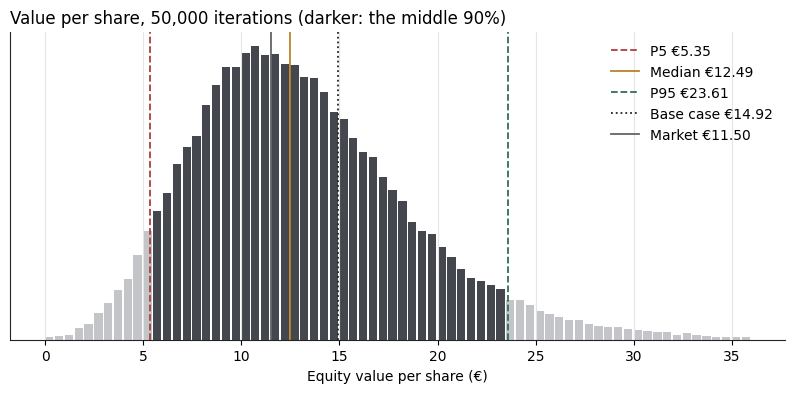

In [6]:
edges = np.arange(0, 36.01, 0.5); h, e = np.histogram(v, edges); mid = (e[:-1] + e[1:]) / 2
fig, ax = plt.subplots()
ax.bar(e[:-1], h, width=0.42, align='edge', color=[BAR if s['p5'] <= x <= s['p95'] else BARL for x in mid])
for x, lab, col, ls in [(s['p5'], 'P5', DOWN, '--'), (s['p50'], 'Median', AMB, '-'), (s['p95'], 'P95', UP, '--'), (base, 'Base case', INK, ':'), (P['market'], 'Market', MUTE, '-')]:
    ax.axvline(x, color=col, ls=ls, lw=1.3, label=f'{lab} €{x:.2f}')
ax.set_yticks([]); ax.set_xlabel('Equity value per share (€)'); ax.legend(frameon=False); ax.set_title('Value per share, 50,000 iterations (darker: the middle 90%)', loc='left')
plt.show()

## 4. Why the base case flatters

The base case uses the most-likely value of every input, but a most-likely input does not give the most-likely output when the distributions are lopsided. `bridge()` switches the uncertainty on one input at a time, on the same random numbers, and records the median after each step. The last step switches everything on, so the steps add up exactly to the gap.

In [7]:
b0, steps = bridge()
br = pd.DataFrame([(LABELS[k], dv, m) for k, dv, m in steps], columns=['Uncertainty switched on', 'Change in median (€)', 'Median after (€)'])
print(f'Base case €{b0:.2f} → simulated median €{steps[-1][2]:.2f}; steps sum to €{sum(x[1] for x in steps):.2f}')
br

Base case €14.92 → simulated median €12.49; steps sum to €-2.43


,Uncertainty switched on,Change in median (€),Median after (€)
0,Tax rate,-0.6905,14.2260
1,CapEx (% of revenue),-0.8057,13.4203
2,EBITDA margin,-0.6620,12.7584
3,Terminal growth,-0.1922,12.5662
4,Revenue growth,-0.1015,12.4647
5,WACC,0.0224,12.4871


## 5. What moves value

Spearman rank correlation of each input with value per share, and each input's share of the explained variance (squared correlation over the total).

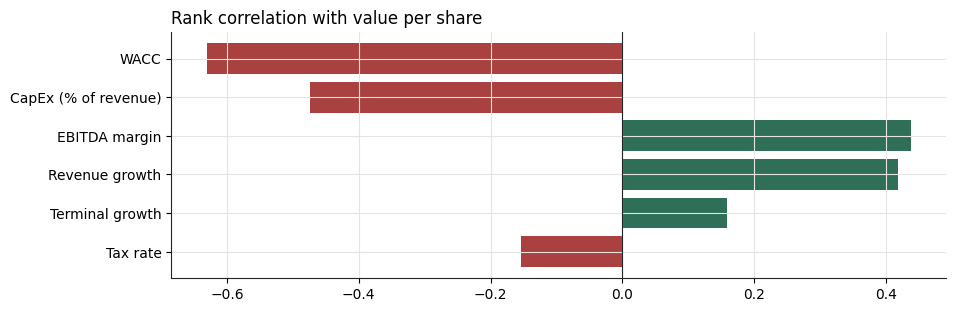

,Rank correlation,Share of variance
Driver,,
WACC,-0.6308,0.3837
CapEx (% of revenue),-0.4738,0.2165
EBITDA margin,0.4378,0.1849
Revenue growth,0.4172,0.1679
Terminal growth,0.1586,0.0242
Tax rate,-0.1535,0.0227


In [8]:
se = pd.DataFrame([(LABELS[k], r, sh) for k, r, sh in sensitivity(d, v)], columns=['Driver', 'Rank correlation', 'Share of variance']).set_index('Driver')
fig, ax = plt.subplots(figsize=(10, 3.2))
ax.barh(se.index[::-1], se['Rank correlation'][::-1], color=[DOWN if x < 0 else UP for x in se['Rank correlation'][::-1]])
ax.axvline(0, color=INK, lw=0.8); ax.set_title('Rank correlation with value per share', loc='left'); plt.show()
se

## 6. How many iterations are enough?

A Monte Carlo result is itself an estimate. `convergence()` re-runs the whole simulation 200 times with fresh random numbers at each size and measures how much the median and the tails move. The half-width of the 95% range is 1.96 standard deviations.

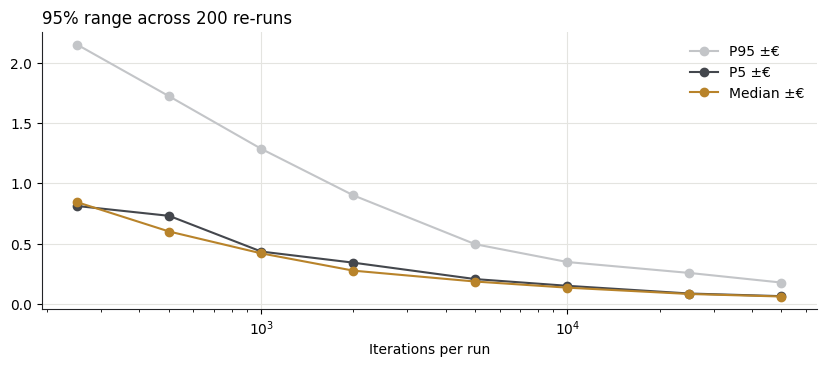

,Median ±€,P5 ±€,P95 ±€,P(value > price) ± pts
n,,,,
250,0.8440,0.8120,2.1514,6.0430
500,0.6002,0.7302,1.7221,4.5015
1000,0.4189,0.4338,1.2858,3.1716
2000,0.2754,0.3416,0.8999,2.0097
5000,0.1852,0.2055,0.4946,1.4004
10000,0.1344,0.1497,0.3470,0.9963
25000,0.0819,0.0858,0.2566,0.5927
50000,0.0609,0.0639,0.1766,0.4400


In [9]:
cv = pd.DataFrame(convergence()).set_index('n')
tbl = (1.96 * cv[['med_sd', 'p5_sd', 'p95_sd']]).rename(columns={'med_sd': 'Median ±€', 'p5_sd': 'P5 ±€', 'p95_sd': 'P95 ±€'})
tbl['P(value > price) ± pts'] = 1.96 * cv['pm_sd'] * 100
fig, ax = plt.subplots(figsize=(10, 3.6))
for c, col in zip(['P95 ±€', 'P5 ±€', 'Median ±€'], [BARL, BAR, AMB]): ax.plot(tbl.index, tbl[c], marker='o', color=col, label=c)
ax.set_xscale('log'); ax.legend(frameon=False); ax.set_xlabel('Iterations per run'); ax.set_title('95% range across 200 re-runs', loc='left'); plt.show()
tbl

The error falls with the square root of the iterations, and the tails converge more slowly than the centre: 2,000 iterations (the Excel workbook) are enough to place the median within about ±€0.30, but P95 needs tens of thousands.

## 7. The windfall tax as an event

The base model gives the tax rate a long tail up to 35%. In practice a windfall tax either happens or not. The event model keeps an ordinary rate of 24% to 28% and adds a 9-point surcharge with a 25% probability, so the average tax is the same. Using the same seed, every other input is identical run by run.

Value riding on the decision: €3.09 per share (difference in medians)


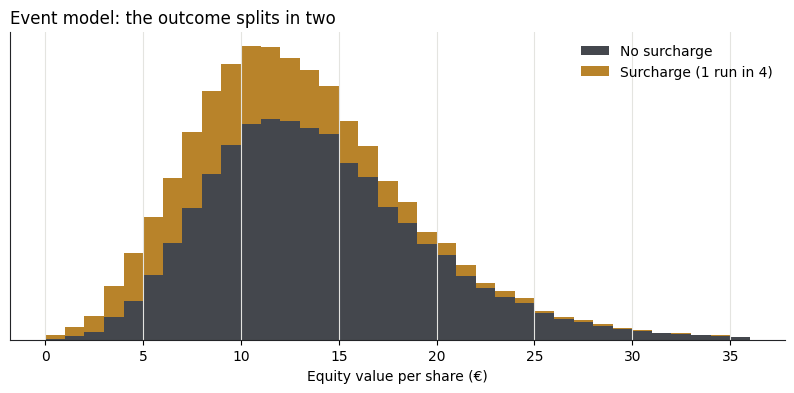

,Continuous tax tail,Event model,Event: no surcharge,Event: surcharge
Average tax,0.2832,0.2826,0.2600,0.3500
Median (€),12.4871,12.5272,13.2911,10.2005
P5 (€),5.3545,5.1030,6.0595,3.6532
P(value > price),0.5748,0.5756,0.6357,0.3969


In [10]:
dw, vw = run(tax_model='event'); ev = dw['event']; sw = stats(vw)
wf = pd.DataFrame({'Continuous tax tail': [d['tax'].mean(), s['p50'], s['p5'], s['p_mkt']],
                   'Event model': [dw['tax'].mean(), sw['p50'], sw['p5'], sw['p_mkt']],
                   'Event: no surcharge': [dw['tax'][~ev].mean(), np.median(vw[~ev]), np.percentile(vw[~ev], 5), (vw[~ev] > P['market']).mean()],
                   'Event: surcharge': [dw['tax'][ev].mean(), np.median(vw[ev]), np.percentile(vw[ev], 5), (vw[ev] > P['market']).mean()]},
                  index=['Average tax', 'Median (€)', 'P5 (€)', 'P(value > price)'])
print(f'Value riding on the decision: €{np.median(vw[~ev]) - np.median(vw[ev]):.2f} per share (difference in medians)')
fig, ax = plt.subplots()
e2 = np.arange(0, 36.01, 1.0)
ax.hist([vw[~ev], vw[ev]], e2, stacked=True, color=[BAR, AMB], label=['No surcharge', 'Surcharge (1 run in 4)'])
ax.set_yticks([]); ax.legend(frameon=False); ax.set_xlabel('Equity value per share (€)'); ax.set_title('Event model: the outcome splits in two', loc='left'); plt.show()
wf

The headline barely moves, but the event model shows that about €3 of value per share rides on one political decision: something to monitor, not a tail to average away.

## 8. Share-price paths

A separate question: how might the share price travel over five years? Geometric Brownian Motion from the €11.50 market price, monthly steps, 7% drift and 38% volatility. This is not linked to the DCF: one values the company today, the other shows the range of paths.

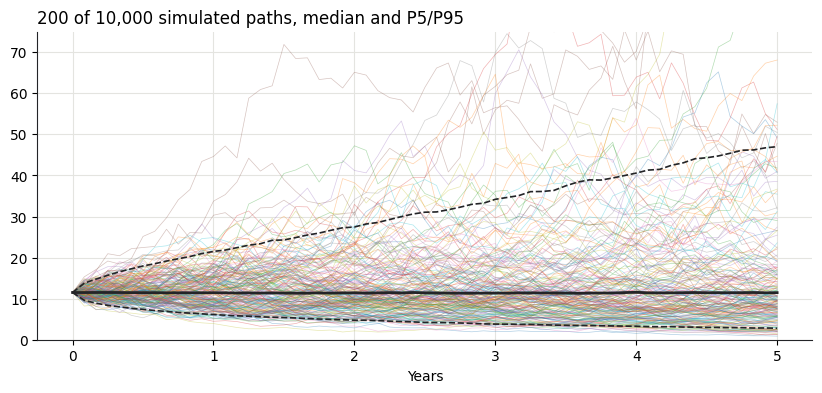

After five years: P5 €2.79 · median €11.46 · P95 €47.01


In [11]:
pth, _ = paths(); t = np.arange(pth.shape[1]) / 12
fig, ax = plt.subplots()
ax.plot(t, pth[:200].T, lw=0.5, alpha=0.35)
for q, ls in [(50, '-'), (5, '--'), (95, '--')]: ax.plot(t, np.percentile(pth, q, 0), color=INK, lw=2 if q == 50 else 1.2, ls=ls)
ax.set_ylim(0, 75); ax.set_xlabel('Years'); ax.set_title('200 of 10,000 simulated paths, median and P5/P95', loc='left'); plt.show()
print('After five years: P5 €{:.2f} · median €{:.2f} · P95 €{:.2f}'.format(*np.percentile(pth[:, -1], [5, 50, 95])))

## 9. Reconciliation with the Excel workbook

The workbook holds the first 2,000 of the 50,000 draws as raw random numbers (`Random Draws`), turns them into inputs through the distributions on `Assumptions`, and values each row with formulas (`Simulation`). This cell reads the workbook, checks that its assumptions match the engine, recomputes every row from the same random numbers and compares.

In [12]:
import os
from openpyxl import load_workbook
if not os.path.exists('Lumina_MonteCarlo.xlsx'):
    print('Put Lumina_MonteCarlo.xlsx in this folder to run the reconciliation.')
else:
    wb = load_workbook('Lumina_MonteCarlo.xlsx', data_only=True)
    a = wb['Assumptions']
    xl = {'g': (a['D6'].value, a['E6'].value, a['F6'].value), 'm': (a['D7'].value, a['E7'].value, a['F7'].value), 'wacc': (a['D8'].value, a['E8'].value),
          'tax': (a['D9'].value, a['E9'].value, a['F9'].value), 'tg': (a['D10'].value, a['E10'].value, a['F10'].value), 'cx': (a['D11'].value, a['E11'].value, a['F11'].value)}
    same = all(np.allclose(xl[k], P[k]) for k in xl)
    rd = pd.DataFrame(list(wb['Random Draws'].iter_rows(min_row=6, max_row=2005, min_col=3, max_col=9, values_only=True)),
                      columns=['z1', 'e2', 'zw', 'u_tax', 'u_tg', 'u_cx', 'u_ev'])
    excel_v = np.array([r[0] for r in wb['Simulation'].iter_rows(min_row=6, max_row=2005, min_col=21, max_col=21, values_only=True)], float)
    py_v = value(from_raw({k: rd[k].to_numpy(float) for k in rd}))
    gap = np.abs(excel_v - py_v)
    print(f'Assumptions identical: {same}')
    print(f'Rows compared: {len(gap):,} · largest gap: €{gap.max():.2e} · median Excel €{np.median(excel_v):.4f} vs Python €{np.median(py_v):.4f}')
    print('Excel base case €{:.6f} vs Python €{:.6f}'.format(wb['DCF Base Case']['C36'].value, base))

Assumptions identical: True
Rows compared: 2,000 · largest gap: €6.04e-14 · median Excel €12.5539 vs Python €12.5539
Excel base case €14.916493 vs Python €14.916493


## 10. Summary

In [13]:
pd.Series({'Base case (€)': base, 'Simulated median (€)': s['p50'], 'Mean (€)': s['mean'], 'P5 (€)': s['p5'], 'P95 (€)': s['p95'],
           'P(value > market)': s['p_mkt'], 'Base case above median': base / s['p50'] - 1, 'WACC share of variance': se.loc['WACC', 'Share of variance'],
           'Median ± at 2,000 iterations (€)': tbl.loc[2000, 'Median ±€'], 'Windfall: value at stake (€)': np.median(vw[~ev]) - np.median(vw[ev])}).to_frame('Result')

,Result
Base case (€),14.9165
Simulated median (€),12.4871
Mean (€),13.2258
P5 (€),5.3545
P95 (€),23.6123
P(value > market),0.5748
Base case above median,0.1946
WACC share of variance,0.3837
"Median ± at 2,000 iterations (€)",0.2754
Windfall: value at stake (€),3.0906
